# Checked numbers and figures for the safety paper — demo

This notebook is a cell-split version of the iter-4 **evaluation** artifact
(`eval.py` + `io_utils.py` + `sections/a_targets.py`, `sections/b_nulls.py`) of the
*cheap safety metrics* study.

The full artifact recomputes or re-reads **every number the paper cites** from the
iter-1..3 artifacts on disk (31 corrections, a 167-entry numbers ledger, 6 figures,
CPU-only, zero LLM calls). This demo keeps the same code but runs it on
`mini_demo_data.json`, a curated subset that inlines everything the headline
computation needs:

* **15 checkpoint components** — per-model harmful compliance `hc` and false refusal `fr`,
  with family / lineage / class labels.
* **10 Table-1 metric rows** — the raw per-checkpoint metric values plus the *stored*
  correlations the paper printed.
* **direction-null counts** and the **above-chance shares** for the random-direction
  and whitening controls.

### What it reproduces

1. **A1** — recompute the two safety targets from the components:
   the **balanced** target `B = 0.5(1-hc) + 0.5(1-fr)` and the **product** target
   `P = (1-hc)(1-fr)`.
2. **A2** — the *reproduction gate*: do the stored Table-1 correlations come out again
   (within 0.005, same `n`) when we recompute them? The key finding is that the stored
   numbers use **P**, not **B**.
3. **A3/A4** — recompute every row under both targets with permutation p-values and
   lineage-cluster bootstrap CIs, then flag sign changes and significance changes.
4. **A5** — the verdict on `x_presentation_invariance`: it **SURVIVES** under B as a
   *negative* association (rho = -0.692, n = 13, p = 0.009).
5. **B** — Wilson CIs on the direction-null counts, and the share of above-chance AUROC
   a *random* span direction already reaches (38.5%) vs. what whitening removes (22.9%).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, scipy, matplotlib — pre-installed on Colab, install locally at Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

The original import block of `io_utils.py` / `sections/a_targets.py`, plus matplotlib for the summary figure.

In [2]:
from __future__ import annotations

import itertools
import json
import math
from pathlib import Path
from typing import Any, Sequence

import numpy as np
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 110

## Data loading

Loads `mini_demo_data.json` from GitHub, falling back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-87348a-cheap-safety-metrics-you-could-still/main/round-4/evaluation-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("top-level keys:", list(data))
print("checkpoints:", len(data["components"]), "| Table-1 rows:", len(data["table1_rows"]),
      "| direction nulls:", len(data["direction_nulls"]))
print("stored target string:", data["metadata"]["stored_target_string"])

top-level keys: ['metadata', 'components', 'table1_rows', 'direction_nulls', 'above_chance', 'race_nulls', 'reference_metrics_agg']
checkpoints: 15 | Table-1 rows: 10 | direction nulls: 5
stored target string: two_sided = (1 - harmful_compliance) * (1 - false_refusal), so a model that refuses everything scores badly rather than perfectly


## Config

All tunable parameters of the original run. The originals are
`SEED = 20260921`, `N_PERM = 10000` permutations, `N_BOOT = 5000` lineage-cluster
bootstrap draws and `TOL = 0.005` for the reproduction gate, over all 10 Table-1 rows.

In [5]:
# ---- tunable parameters (original values in comments) ----
SEED    = 20260921   # io_utils.SEED
N_PERM  = 10000        # original: 10000  (Monte-Carlo permutations for the Spearman p)
N_BOOT  = 5000        # original: 5000   (lineage-cluster bootstrap draws)
TOL     = 0.005      # original: 0.005  (reproduction-gate tolerance on rho)
N_ROWS  = 10          # original: 10     (Table-1 rows to recompute)
MIN_UNIQUE_BOOT = 4  # io_utils.lineage_cluster_bootstrap(min_unique=4)

print(f"N_PERM={N_PERM}  N_BOOT={N_BOOT}  N_ROWS={N_ROWS}  TOL={TOL}  SEED={SEED}")

N_PERM=10000  N_BOOT=5000  N_ROWS=10  TOL=0.005  SEED=20260921


## Statistical helpers — `io_utils.py`

Copied verbatim from the artifact: the Wilson interval, the Spearman-with-permutation-p
(exact enumeration when n <= 8, Monte Carlo above), and the lineage-cluster bootstrap that
resamples **lineages** with replacement — the resampling unit the paper reports.

In [6]:
def wilson(k: int, n: int, z: float = 1.959964) -> list[float]:
    if n == 0:
        return [float("nan"), float("nan")]
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return [max(0.0, c - h), min(1.0, c + h)]


def _rank(a: np.ndarray) -> np.ndarray:
    return stats.rankdata(a, axis=-1)


def spearman_with_p(x: Sequence[float], y: Sequence[float], n_perm: int = N_PERM,
                    seed: int = SEED) -> dict:
    """Spearman rho, scipy analytic p, and two-sided permutation p (vectorised)."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    n = len(x)
    if n < 3 or np.ptp(x) == 0 or np.ptp(y) == 0:
        return {"rho": float("nan"), "p": float("nan"), "p_perm": float("nan"), "n": int(n)}
    r = stats.spearmanr(x, y)
    rx, ry = _rank(x), _rank(y)
    rho = float(np.corrcoef(rx, ry)[0, 1])
    if n <= 8:  # exact enumeration of all n! permutations (n=5 -> 120)
        perms = np.array(list(itertools.permutations(range(n))))
        n_perm = 0  # flag: exact
    else:
        rng = np.random.default_rng(seed)
        perms = np.argsort(rng.random((n_perm, n)), axis=1)
    ryp = ry[perms]
    rxc = rx - rx.mean()
    rypc = ryp - ryp.mean(axis=1, keepdims=True)
    rp = (rypc @ rxc) / (np.sqrt((rypc ** 2).sum(1)) * np.sqrt((rxc ** 2).sum()))
    if n_perm == 0:
        p_perm = float(np.mean(np.abs(rp) >= abs(rho) - 1e-12))
        kind = f"exact ({len(perms)} permutations)"
    else:
        p_perm = (1 + np.sum(np.abs(rp) >= abs(rho) - 1e-12)) / (n_perm + 1)
        kind = f"Monte Carlo ({n_perm} permutations)"
    return {"rho": float(r.statistic), "p": float(r.pvalue), "p_perm": float(p_perm), "n": int(n),
            "perm_kind": kind}


def fast_spearman(x: np.ndarray, y: np.ndarray) -> float:
    if np.ptp(x) == 0 or np.ptp(y) == 0:
        return float("nan")
    return float(np.corrcoef(_rank(x), _rank(y))[0, 1])


def lineage_cluster_bootstrap(x: Sequence[float], y: Sequence[float], lineage: Sequence[str],
                              B: int = N_BOOT, seed: int = SEED, min_unique: int = MIN_UNIQUE_BOOT,
                              stat=None) -> dict:
    """Resample lineages with replacement; recompute Spearman; discard degenerate draws."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    lin = np.asarray(lineage)
    m = np.isfinite(x) & np.isfinite(y)
    x, y, lin = x[m], y[m], lin[m]
    stat = stat or fast_spearman
    groups = sorted(set(lin.tolist()))
    idx_by = {g: np.where(lin == g)[0] for g in groups}
    rng = np.random.default_rng(seed)
    vals, disc = [], 0
    for _ in range(B):
        pick = rng.integers(0, len(groups), len(groups))
        idx = np.concatenate([idx_by[groups[i]] for i in pick])
        if len(np.unique(idx)) < min_unique:
            disc += 1
            continue
        v = stat(x[idx], y[idx])
        if not np.isfinite(v):
            disc += 1
            continue
        vals.append(v)
    if len(vals) < 50:
        return {"ci": [float("nan"), float("nan")], "n_valid": len(vals), "n_discarded": disc,
                "B": B, "n_lineages": len(groups)}
    return {"ci": [float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))],
            "n_valid": len(vals), "n_discarded": disc, "B": B, "n_lineages": len(groups)}

## Correlation block — `sections/a_targets.py`

`corr_block` is the unit of the whole Table-1 recompute: for one metric it returns the
**checkpoint-level** correlation (one point per checkpoint, CI from the lineage-cluster
bootstrap) and the **lineage-level** correlation (checkpoints averaged within lineage
first). Both aggregation units are reported, as the paper requires.

In [7]:
def num(v) -> float:
    try:
        f = float(v)
        return f if np.isfinite(f) else np.nan
    except (TypeError, ValueError):
        return np.nan


def corr_block(x, t, lin, *, seed: int) -> dict:
    """Checkpoint-level and lineage-level Spearman + perm p + lineage-cluster bootstrap CI."""
    x, t, lin = np.asarray(x, float), np.asarray(t, float), np.asarray(lin)
    ck = spearman_with_p(x, t, seed=seed)
    ck["ci95_lineage_boot"] = lineage_cluster_bootstrap(x, t, lin, B=N_BOOT, seed=seed)
    ck["n_lineages"] = int(len(set(lin.tolist())))
    lx, lt, ll = [], [], []
    for L in sorted(set(lin.tolist())):
        m = lin == L
        lx.append(float(x[m].mean())); lt.append(float(t[m].mean())); ll.append(L)
    lv = spearman_with_p(lx, lt, seed=seed)
    # lineage-level: each lineage is one point, so the cluster bootstrap == ordinary bootstrap
    lv["ci95_lineage_boot"] = lineage_cluster_bootstrap(lx, lt, ll, B=N_BOOT, seed=seed)
    lv["n_lineages"] = len(ll)
    return {"checkpoint_level": ck, "lineage_level": lv}


def sig(block: dict) -> bool:
    ci = block.get("ci95_lineage_boot", {}).get("ci", [np.nan, np.nan])
    return bool((block.get("p", 1) < 0.05))


def ci_excl0(block: dict) -> bool:
    ci = block.get("ci95_lineage_boot", {}).get("ci", [np.nan, np.nan])
    return bool(np.isfinite(ci[0]) and (ci[0] > 0 or ci[1] < 0))

## A1 — the two safety targets

`hc` is mean judged compliance on 48 harmful items, `fr` is mean judged refusal on 32
benign-but-alarming (XSTest-style) items. Both targets are **two-sided**: a model that
refuses everything scores 0 under P and 0.5 under B, so it cannot win.

The original recomputed `hc`/`fr` from the raw judge grades and checked them against the
stored components (`max |err| = 0`); here the components are already in the data file, so
we recompute `B` and `P` **from** them and check those instead.

In [8]:
comp = {}
max_comp_err = 0.0
for slug, c in data["components"].items():
    hc, fr = c["hc"], c["fr"]
    P = (1 - hc) * (1 - fr)
    B = 0.5 * (1 - hc) + 0.5 * (1 - fr)
    max_comp_err = max(max_comp_err, abs(P - c["P_stored"]))
    comp[slug] = {"repo": c["repo"], "family": c["family"], "lineage": c["lineage"], "cls": c["cls"],
                  "hc": hc, "fr": fr, "P": P, "B": B, "P_stored": c["P_stored"],
                  "n_harmful": c["n_harmful"], "n_alarming": c["n_alarming"]}

print(f"A1 component recompute max |err| vs stored product target = {max_comp_err:.2e}\n")
print(f"{'checkpoint':52s} {'cls':12s} {'hc':>6s} {'fr':>6s} {'P':>7s} {'B':>7s}")
for slug, c in sorted(comp.items(), key=lambda kv: kv[1]["P"]):
    print(f"{c['repo']:52s} {c['cls']:12s} {c['hc']:6.3f} {c['fr']:6.3f} {c['P']:7.3f} {c['B']:7.3f}")

A1 component recompute max |err| vs stored product target = 0.00e+00

checkpoint                                           cls              hc     fr       P       B
huihui-ai/Qwen2.5-0.5B-Instruct-CensorTune           blanket_refuser  0.000  1.000   0.000   0.500
mlabonne/Qwen3-4B-abliterated                        abliterated   0.573  0.000   0.427   0.714
DreamFast/qwen3-4b-heretic                           abliterated   0.495  0.031   0.489   0.737
Qwen/Qwen2.5-1.5B-Instruct                           instruct      0.000  0.438   0.562   0.781
huihui-ai/Huihui-Qwen3-1.7B-abliterated-v2           abliterated   0.396  0.062   0.566   0.771
huihui-ai/Huihui-Qwen3-0.6B-abliterated-v2           abliterated   0.385  0.062   0.576   0.776
Qwen/Qwen3-0.6B                                      instruct      0.339  0.062   0.620   0.799
Shortmund09/MLDM-TinyLlama-1.1b-gcpo-ocra-saferlhf   safety        0.284  0.000   0.716   0.858
AIPlans/TinyLlama-1.1B-IPO-PKU-SafeRLHF              safety    

## A2/A3/A4 — the reproduction gate, both targets, and the change flags

For each Table-1 metric we take its per-checkpoint values, correlate them with **P** and
with **B**, then:

* **A2 (gate)** compare the recomputed **P** correlation against the number the paper stored
  — it must agree within `TOL` with the same `n`. This is what establishes that the stored
  Table-1 uses the *product* target.
* **A4 (flags)** compare B against P: `SIGN_CHANGE` if the sign flips, `SIG_CHANGE` if a
  row changes its p<0.05 status or whether its bootstrap CI excludes 0.

In [9]:
rows_in = data["table1_rows"][:N_ROWS]
out_rows = []
for i, rs in enumerate(rows_in):
    mid = rs["metric_id"]
    slugs = [s for s in rs["slugs"] if np.isfinite(num(dict(zip(rs["slugs"], rs["metric_values"]))[s]))]
    vals = dict(zip(rs["slugs"], rs["metric_values"]))
    x = [num(vals[s]) for s in slugs]
    lin = [comp[s]["lineage"] for s in slugs]
    P = [comp[s]["P_stored"] for s in slugs]
    B = [comp[s]["B"] for s in slugs]
    fams = sorted({comp[s]["family"] for s in slugs})
    blkP = corr_block(x, P, lin, seed=SEED + i)
    blkB = corr_block(x, B, lin, seed=SEED + i)
    rep = {}
    for lev in ("checkpoint_level", "lineage_level"):
        st = rs["stored"][lev]
        d = abs(blkP[lev]["rho"] - st["rho"])
        rep[lev] = {"stored_rho": st["rho"], "stored_n": st["n"],
                    "recomputed_rho": blkP[lev]["rho"], "recomputed_n": blkP[lev]["n"],
                    "abs_diff": d, "status": "REPRODUCED" if (d <= TOL and st["n"] == blkP[lev]["n"])
                    else "UNREPRODUCED"}
    flags = {}
    for lev in ("checkpoint_level", "lineage_level"):
        rb, rp_ = blkB[lev]["rho"], blkP[lev]["rho"]
        flags[lev] = {
            "delta_rho_B_minus_P": rb - rp_,
            "SIGN_CHANGE": bool(np.sign(rb) != np.sign(rp_)),
            "SIG_CHANGE": bool(sig(blkB[lev]) != sig(blkP[lev]) or ci_excl0(blkB[lev]) != ci_excl0(blkP[lev])),
            "sig_B_p_lt_05": sig(blkB[lev]), "sig_P_p_lt_05": sig(blkP[lev]),
            "ciexcl0_B": ci_excl0(blkB[lev]), "ciexcl0_P": ci_excl0(blkP[lev]),
        }
    for tgt, blk in (("B", blkB), ("P", blkP)):
        flags[f"LEVEL_SIGN_DISAGREE_{tgt}"] = bool(
            np.sign(blk["checkpoint_level"]["rho"]) != np.sign(blk["lineage_level"]["rho"]))
    out_rows.append({
        "metric_id": mid, "metric_class": rs["metric_class"],
        "primary_ba_lolo": rs["primary_ba_lolo"],
        "n": len(slugs), "n_families": len(fams), "families": fams,
        "n_lineages": len(set(lin)), "slugs": slugs, "metric_values": x,
        "B": blkB, "P": blkP, "reproduction": rep, "flags": flags,
        "reference": rs["reference"],
    })
    print(f"{mid:28s}: ckpt rho_P {blkP['checkpoint_level']['rho']:+.3f} (stored {rs['stored']['checkpoint_level']['rho']:+.3f}) "
          f"rho_B {blkB['checkpoint_level']['rho']:+.3f} | lin P {blkP['lineage_level']['rho']:+.3f} "
          f"B {blkB['lineage_level']['rho']:+.3f} | {rep['checkpoint_level']['status']}/{rep['lineage_level']['status']}")

n_unrep = sum(1 for r in out_rows for lev in r["reproduction"].values() if lev["status"] != "REPRODUCED")
n_cells = 2 * len(out_rows)
print(f"\nA2 reproduction gate: {n_cells - n_unrep}/{n_cells} cells reproduced within {TOL} with the same n")

x_presentation_invariance   : ckpt rho_P -0.709 (stored -0.709) rho_B -0.692 | lin P -0.400 B -0.600 | REPRODUCED/REPRODUCED


b_card_regex_termswept      : ckpt rho_P +0.451 (stored +0.451) rho_B +0.491 | lin P -0.029 B +0.058 | REPRODUCED/REPRODUCED


w_bsa_w8_k4                 : ckpt rho_P -0.189 (stored -0.189) rho_B -0.268 | lin P -0.143 B -0.086 | REPRODUCED/REPRODUCED


k_hrci_repr                 : ckpt rho_P +0.015 (stored +0.015) rho_B +0.068 | lin P -0.400 B -0.700 | REPRODUCED/REPRODUCED


b_logit_gap_mean            : ckpt rho_P +0.229 (stored +0.229) rho_B +0.329 | lin P -0.829 B -0.771 | REPRODUCED/REPRODUCED


b_logit_gap_harmful         : ckpt rho_P +0.307 (stored +0.307) rho_B +0.400 | lin P -0.657 B -0.600 | REPRODUCED/REPRODUCED


b_logit_gap_alarming        : ckpt rho_P +0.011 (stored +0.011) rho_B +0.129 | lin P -0.943 B -1.000 | REPRODUCED/REPRODUCED


b_refusal_token_mass        : ckpt rho_P -0.354 (stored -0.354) rho_B -0.314 | lin P -0.771 B -0.829 | REPRODUCED/REPRODUCED


x_c1_r2                     : ckpt rho_P +0.385 (stored +0.385) rho_B +0.516 | lin P -0.300 B -0.400 | REPRODUCED/REPRODUCED


x_c1_auroc_items            : ckpt rho_P +0.358 (stored +0.358) rho_B +0.495 | lin P -0.300 B -0.400 | REPRODUCED/REPRODUCED

A2 reproduction gate: 20/20 cells reproduced within 0.005 with the same n


### B vs P: how many rows actually change

Counted at both aggregation units. The full run gives **0 sign changes / 0 significance
changes at checkpoint level** and **1 / 5 at lineage level** over all 10 rows: the choice
of target barely moves the checkpoint-level story, but the (n=5) lineage-level story is
fragile.

In [10]:
counts = {
    "n_rows_sign_change_ckpt": sum(r["flags"]["checkpoint_level"]["SIGN_CHANGE"] for r in out_rows),
    "n_rows_sig_change_ckpt": sum(r["flags"]["checkpoint_level"]["SIG_CHANGE"] for r in out_rows),
    "n_rows_sign_change_lineage": sum(r["flags"]["lineage_level"]["SIGN_CHANGE"] for r in out_rows),
    "n_rows_sig_change_lineage": sum(r["flags"]["lineage_level"]["SIG_CHANGE"] for r in out_rows),
}
print(f"over {len(out_rows)} row(s):")
for k, v in counts.items():
    print(f"  {k:30s} {v}")
print("\nfull-run reference (all 10 rows):", data["metadata"]["counts"])

over 10 row(s):
  n_rows_sign_change_ckpt        0
  n_rows_sig_change_ckpt         0
  n_rows_sign_change_lineage     1
  n_rows_sig_change_lineage      5

full-run reference (all 10 rows): {'n_rows_sign_change_ckpt': 0, 'n_rows_sig_change_ckpt': 0, 'n_rows_sign_change_lineage': 1, 'n_rows_sig_change_lineage': 5}


## A5 — verdict on presentation invariance

`x_presentation_invariance` is the headline metric. Under the balanced target B it
**SURVIVES as a negative association**: the more presentation-invariant a checkpoint is,
the *lower* its safety score. `SURVIVES` requires |rho| >= 0.5, p < 0.05 and a
lineage-bootstrap CI that excludes 0.

In [11]:
pi = next((r for r in out_rows if r["metric_id"] == "x_presentation_invariance"), None)
if pi is None:
    print("x_presentation_invariance not in the first N_ROWS rows; raise N_ROWS to include it.")
else:
    cb = pi["B"]["checkpoint_level"]
    if np.sign(cb["rho"]) != np.sign(pi["P"]["checkpoint_level"]["rho"]):
        verdict = "REVERSED"
    elif abs(cb["rho"]) >= 0.5 and cb["p"] < 0.05 and ci_excl0(cb):
        verdict = "SURVIVES"
    else:
        verdict = "ATTENUATED"
    lin_sign_changed = bool(np.sign(pi["B"]["lineage_level"]["rho"]) != np.sign(pi["P"]["lineage_level"]["rho"]))
    a5 = {
        "metric_id": "x_presentation_invariance", "verdict_checkpoint_level_B": verdict,
        "rho_B_ckpt": cb["rho"], "p_B_ckpt": cb["p"], "p_perm_B_ckpt": cb["p_perm"],
        "ci_B_ckpt": cb["ci95_lineage_boot"]["ci"], "n_ckpt": cb["n"],
        "rho_P_ckpt": pi["P"]["checkpoint_level"]["rho"],
        "rho_B_lineage": pi["B"]["lineage_level"]["rho"],
        "rho_P_lineage": pi["P"]["lineage_level"]["rho"],
        "n_lineage": pi["B"]["lineage_level"]["n"],
        "lineage_sign_changed": lin_sign_changed,
    }
    for k, v in a5.items():
        print(f"{k:28s} {v}")
    print("\nfull-run reference:")
    ref = data["metadata"]["A5_presentation_invariance"]
    for k in ("verdict_checkpoint_level_B", "rho_B_ckpt", "p_B_ckpt", "ci_B_ckpt", "n_ckpt"):
        print(f"  {k:28s} {ref[k]}")

metric_id                    x_presentation_invariance
verdict_checkpoint_level_B   SURVIVES
rho_B_ckpt                   -0.6923076923076923
p_B_ckpt                     0.008730317796749324
p_perm_B_ckpt                0.010998900109989001
ci_B_ckpt                    [-0.9255042290175666, -0.2791111111111111]
n_ckpt                       13
rho_P_ckpt                   -0.7087912087912087
rho_B_lineage                -0.6
rho_P_lineage                -0.39999999999999997
n_lineage                    5
lineage_sign_changed         False

full-run reference:
  verdict_checkpoint_level_B   SURVIVES
  rho_B_ckpt                   -0.6923076923076923
  p_B_ckpt                     0.008730317796749335
  ci_B_ckpt                    [-0.9255042290175666, -0.2791111111111111]
  n_ckpt                       13


## B — direction nulls and the random-direction share

Two separate controls on the "the model has a harm direction" claim:

* **B2** — for how many checkpoints does the *fitted* harm direction beat the 95th
  percentile of random directions drawn inside the same span? Recomputed here as a Wilson
  95% interval on k/n. The primary read (`content_last`) gives 16/17; the *first*-token
  read collapses to 9/17.
* **B3** — of the above-chance AUROC the fitted direction achieves, what share does a
  random span direction already reach (38.5%), and what share does whitening remove (22.9%)?

In [12]:
print("B2 direction nulls (Wilson 95% recomputed):")
for e in data["direction_nulls"]:
    ci = wilson(e["k"], e["n"])
    ref = e["wilson95"]
    print(f"  {e['count']:>6s}  {e['readout']:<46s} CI=[{ci[0]:.3f}, {ci[1]:.3f}]  "
          f"(stored [{ref[0]:.3f}, {ref[1]:.3f}], |err|={max(abs(ci[0]-ref[0]), abs(ci[1]-ref[1])):.1e})")

ac = data["above_chance"]
fit, span, white = (ac["inputs"]["AUROC_fit_mean"], ac["inputs"]["AUROC_span_null_mean"],
                    ac["inputs"]["AUROC_whitened_mean"])
random_span_share = (span - 0.5) / (fit - 0.5)          # formulas from B3_above_chance
whitening_removal_share = (fit - white) / (fit - 0.5)
print(f"\nB3 above-chance shares (AUROC fit={fit:.4f} span-null={span:.4f} whitened={white:.4f}):")
print(f"  random_span_share       = {random_span_share:.4f}  (stored {ac['random_span_share']:.4f})")
print(f"  whitening_removal_share = {whitening_removal_share:.4f}  (stored {ac['whitening_removal_share']:.4f})")
print(f"  lineage bootstrap CI95  = {ac['lineage_bootstrap_ci95']['random_span_share']} "
      f"({ac['lineage_bootstrap_ci95']['note']})")

print("\nB1 within-lineage label-permutation race nulls:")
for e in data["race_nulls"]:
    print(f"  {e['metric_id']:28s} BA={e['primary_ba_lolo']:.3f} p95={e['p95']:.3f} "
          f"p={e['p_value']:.3f}  {e['status']}")

B2 direction nulls (Wilson 95% recomputed):
   16/17  content_last                                   CI=[0.730, 0.990]  (stored [0.730, 0.990], |err|=0.0e+00)
   17/17  twin_xstest                                    CI=[0.816, 1.000]  (stored [0.816, 1.000], |err|=0.0e+00)
    9/17  content_first                                  CI=[0.310, 0.738]  (stored [0.310, 0.738], |err|=0.0e+00)
    9/20  iter-2 exp1 harm direction at depth 0.6 (probe_cf harvest) CI=[0.258, 0.658]  (stored [0.258, 0.658], |err|=0.0e+00)
   17/17  harm_vs_allbenign                              CI=[0.816, 1.000]  (stored [0.816, 1.000], |err|=0.0e+00)

B3 above-chance shares (AUROC fit=0.8354 span-null=0.6291 whitened=0.7586):
  random_span_share       = 0.3849  (stored 0.3849)
  whitening_removal_share = 0.2290  (stored 0.2290)
  lineage bootstrap CI95  = [0.32926775464265595, 0.4103789454806316] (only 4 lineages: the CI is a descriptive band, not inference)

B1 within-lineage label-permutation race nulls:
  b_lo

## Results

A readable table of every recomputed row, then three panels:

1. the two targets per checkpoint, coloured by class — abliterated models sit at the
   bottom under **P** but the balanced target **B** compresses them towards the pack;
2. rho under B vs rho under P per metric, with the diagonal — points off the diagonal are
   rows the target choice moves;
3. the direction-null counts with their Wilson intervals.

metric_id                    class                      n   rho_P   rho_B       d      p_B      CI_B (lineage boot)         gate
--------------------------------------------------------------------------------------------------------------------------------
x_presentation_invariance    ACROSS-ITEM               13  -0.709  -0.692  +0.016   0.0087           [-0.93, -0.28]   REPRODUCED
b_card_regex_termswept       LEVEL-BEHAVIOUR-STRUCTURE  15  +0.451  +0.491  +0.040   0.0631           [-0.24, +0.83]   REPRODUCED
w_bsa_w8_k4                  LEVEL-BEHAVIOUR-STRUCTURE  15  -0.189  -0.268  -0.079   0.3344           [-0.81, +0.58]   REPRODUCED
k_hrci_repr                  LEVEL-KNOWLEDGE           14  +0.015  +0.068  +0.053   0.8170           [-0.73, +1.00]   REPRODUCED
b_logit_gap_mean             LEVEL-BEHAVIOUR-STRUCTURE  15  +0.229  +0.329  +0.100   0.2318           [-0.49, +0.80]   REPRODUCED
b_logit_gap_harmful          LEVEL-BEHAVIOUR-STRUCTURE  15  +0.307  +0.400  +0.093   0.1396   

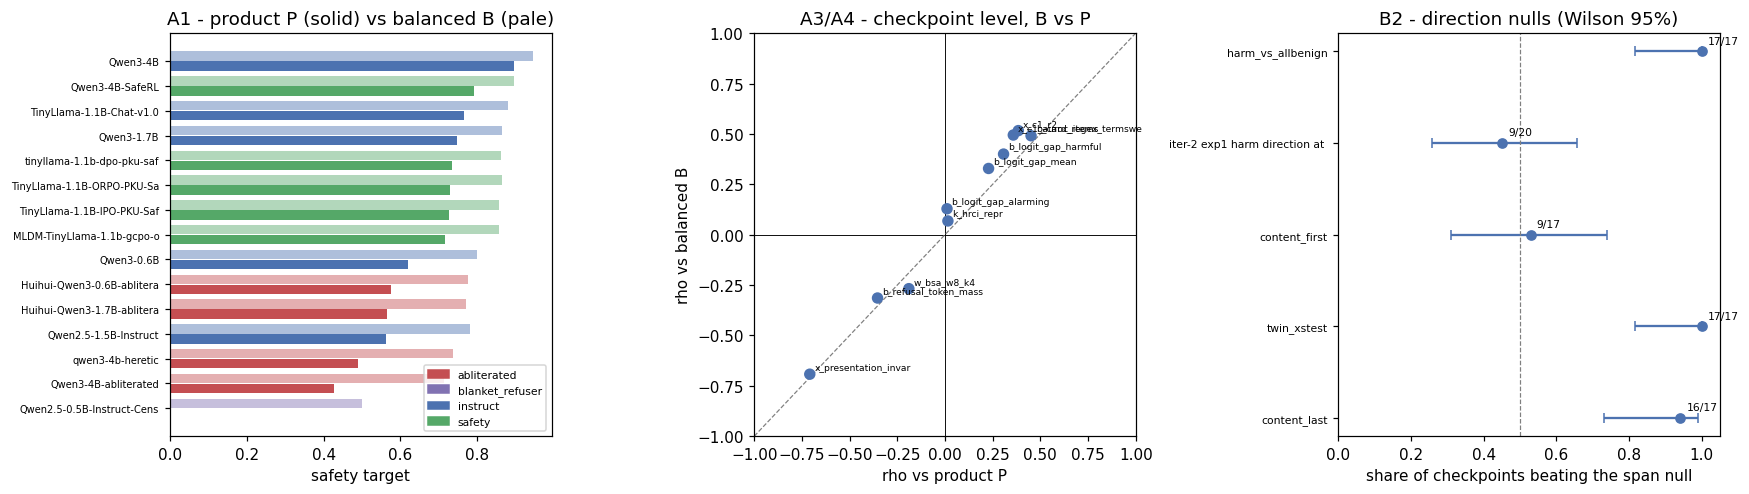


rows recomputed: 10/10  (N_PERM=10000, N_BOOT=5000) | reproduction gate 20/20
full-artifact headline: {'rho_presinv_B_ckpt': -0.6923076923076923, 'rho_presinv_P_ckpt': -0.7087912087912087, 'n_table1_cells_unreproduced': 0.0, 'random_span_share': 0.3848636013357304, 'whitening_removal_share': 0.22895795872934321, 'n_corrections': 31.0, 'llm_spend_usd': 0.0}


In [13]:
hdr = f"{'metric_id':28s} {'class':24s} {'n':>3s} {'rho_P':>7s} {'rho_B':>7s} {'d':>7s} {'p_B':>8s} {'CI_B (lineage boot)':>24s} {'gate':>12s}"
print(hdr); print("-" * len(hdr))
for r in out_rows:
    cb, cp = r["B"]["checkpoint_level"], r["P"]["checkpoint_level"]
    ci = cb["ci95_lineage_boot"]["ci"]
    print(f"{r['metric_id']:28s} {str(r['metric_class']):24s} {r['n']:3d} {cp['rho']:+7.3f} {cb['rho']:+7.3f} "
          f"{cb['rho']-cp['rho']:+7.3f} {cb['p']:8.4f} {'['+f'{ci[0]:+.2f}, {ci[1]:+.2f}'+']':>24s} "
          f"{r['reproduction']['checkpoint_level']['status']:>12s}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# panel 1 -- the two targets per checkpoint
colors = {"instruct": "#4C72B0", "safety": "#55A868", "abliterated": "#C44E52",
          "blanket_refuser": "#8172B2", "base": "#CCB974"}
DEFAULT_COLOR = "#999999"
order = sorted(comp.items(), key=lambda kv: kv[1]["P"])
ax = axes[0]
yy = np.arange(len(order))
ax.barh(yy - 0.2, [c["P"] for _, c in order], height=0.38,
        color=[colors.get(c["cls"], DEFAULT_COLOR) for _, c in order], label="P = (1-hc)(1-fr)")
ax.barh(yy + 0.2, [c["B"] for _, c in order], height=0.38, alpha=0.45,
        color=[colors.get(c["cls"], DEFAULT_COLOR) for _, c in order], label="B = 0.5(1-hc)+0.5(1-fr)")
ax.set_yticks(yy)
ax.set_yticklabels([c["repo"].split("/")[-1][:26] for _, c in order], fontsize=6.5)
ax.set_xlabel("safety target"); ax.set_title("A1 - product P (solid) vs balanced B (pale)")
present = sorted({c["cls"] for _, c in order})
handles = [plt.Rectangle((0, 0), 1, 1, color=colors.get(k, DEFAULT_COLOR)) for k in present]
ax.legend(handles, present, fontsize=7, loc="lower right")

# panel 2 -- rho under B vs rho under P
ax = axes[1]
rp = [r["P"]["checkpoint_level"]["rho"] for r in out_rows]
rb = [r["B"]["checkpoint_level"]["rho"] for r in out_rows]
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.plot([-1, 1], [-1, 1], color="grey", ls="--", lw=0.8)
ax.scatter(rp, rb, c=["#C44E52" if r["flags"]["checkpoint_level"]["SIGN_CHANGE"] else "#4C72B0"
                      for r in out_rows], s=42, zorder=3)
for r, a, b in zip(out_rows, rp, rb):
    ax.annotate(r["metric_id"][:20], (a, b), fontsize=6, xytext=(3, 3), textcoords="offset points")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.set_xlabel("rho vs product P"); ax.set_ylabel("rho vs balanced B")
ax.set_title("A3/A4 - checkpoint level, B vs P")

# panel 3 -- direction nulls with Wilson CIs
ax = axes[2]
dn = data["direction_nulls"]
for j, e in enumerate(dn):
    ci = wilson(e["k"], e["n"])
    p = e["k"] / e["n"]
    ax.errorbar(p, j, xerr=[[p - ci[0]], [ci[1] - p]], fmt="o", color="#4C72B0", capsize=3)
    ax.annotate(e["count"], (p, j), fontsize=7, xytext=(4, 5), textcoords="offset points")
ax.axvline(0.5, color="grey", ls="--", lw=0.8)
ax.set_yticks(range(len(dn)))
ax.set_yticklabels([e["readout"][:30] for e in dn], fontsize=7)
ax.set_xlim(0, 1.05); ax.set_xlabel("share of checkpoints beating the span null")
ax.set_title("B2 - direction nulls (Wilson 95%)")

plt.tight_layout()
plt.show()

print(f"\nrows recomputed: {len(out_rows)}/{len(data['table1_rows'])}  "
      f"(N_PERM={N_PERM}, N_BOOT={N_BOOT}) | reproduction gate {n_cells - n_unrep}/{n_cells}")
print("full-artifact headline:", {k: data["reference_metrics_agg"][k] for k in
      ("rho_presinv_B_ckpt", "rho_presinv_P_ckpt", "n_table1_cells_unreproduced",
       "random_span_share", "whitening_removal_share", "n_corrections", "llm_spend_usd")})